# Lab 3

### Submission And Assignment Instructions
Submit your `Lab3_lastname_firstname.ipynb` file on canvas with your answers clearly marked (✅) and code commented. Skeleton code and/or comments are provided throughout to help you.

- ❓Questions you must answer or tasks are marked with a "❓"
- ✅ Answers you should give are marked with "✅ Answer:"
- *Helpful hints are usually given in italics*
- Code you need to write is marked with `##❓YOUR CODE HERE`
  - ⭐ Bonus questions are marked with a "⭐"
  - 🍓 Bonus answers are marked with a "🍓"

**Please don't erase ANY of these markings!** They're to help the TAs find your answers and code as much as they're to help you find the questions.

## Section 1: Proof of Non-negativity

❓Prove that non-negativity ($0 \leq D(\vec x, \vec y)$) follows from the three properties of a similarity metric. *You may do this math on paper and insert a picture of your work here.*

✅Answer:

Properties: (where D = distance function)
1. Identity: $D(\vec{x}, \vec{y}) = 0 iff \vec{x}, \vec{y}$
2. Symmetry: $D(\vec{x}, \vec{y}) = D(\vec{y}, \vec{x})$
3. Triangle inequality: $D(\vec{x}, \vec{z}) \leq D(\vec{x}, \vec{y}) + D(\vec{y}, \vec{z})$

for any $\vec{x} = \vec{z}$:

by the Triangle inequality: 

$D(\vec{x}, \vec{x}) \leq D(\vec{x}, \vec{y}) + D(\vec{y}, \vec{z})$

$0 \leq D(\vec{x}, \vec{y}) + D(\vec{y}, \vec{x}) = 2*D(\vec{x}, \vec{y})$

$\therefore D(\vec{x}, \vec{y}) \geq 0$

## Section 2: k-NN Visualizations with Toy Data

### 2.1: Visualizing Decision Boundaries
Run the code provided below to visualize the toy dataset and decision boundaries for several different distance metrics and values of $k$.

In [1]:
# !pip install numpy
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn
# !pip install pandas

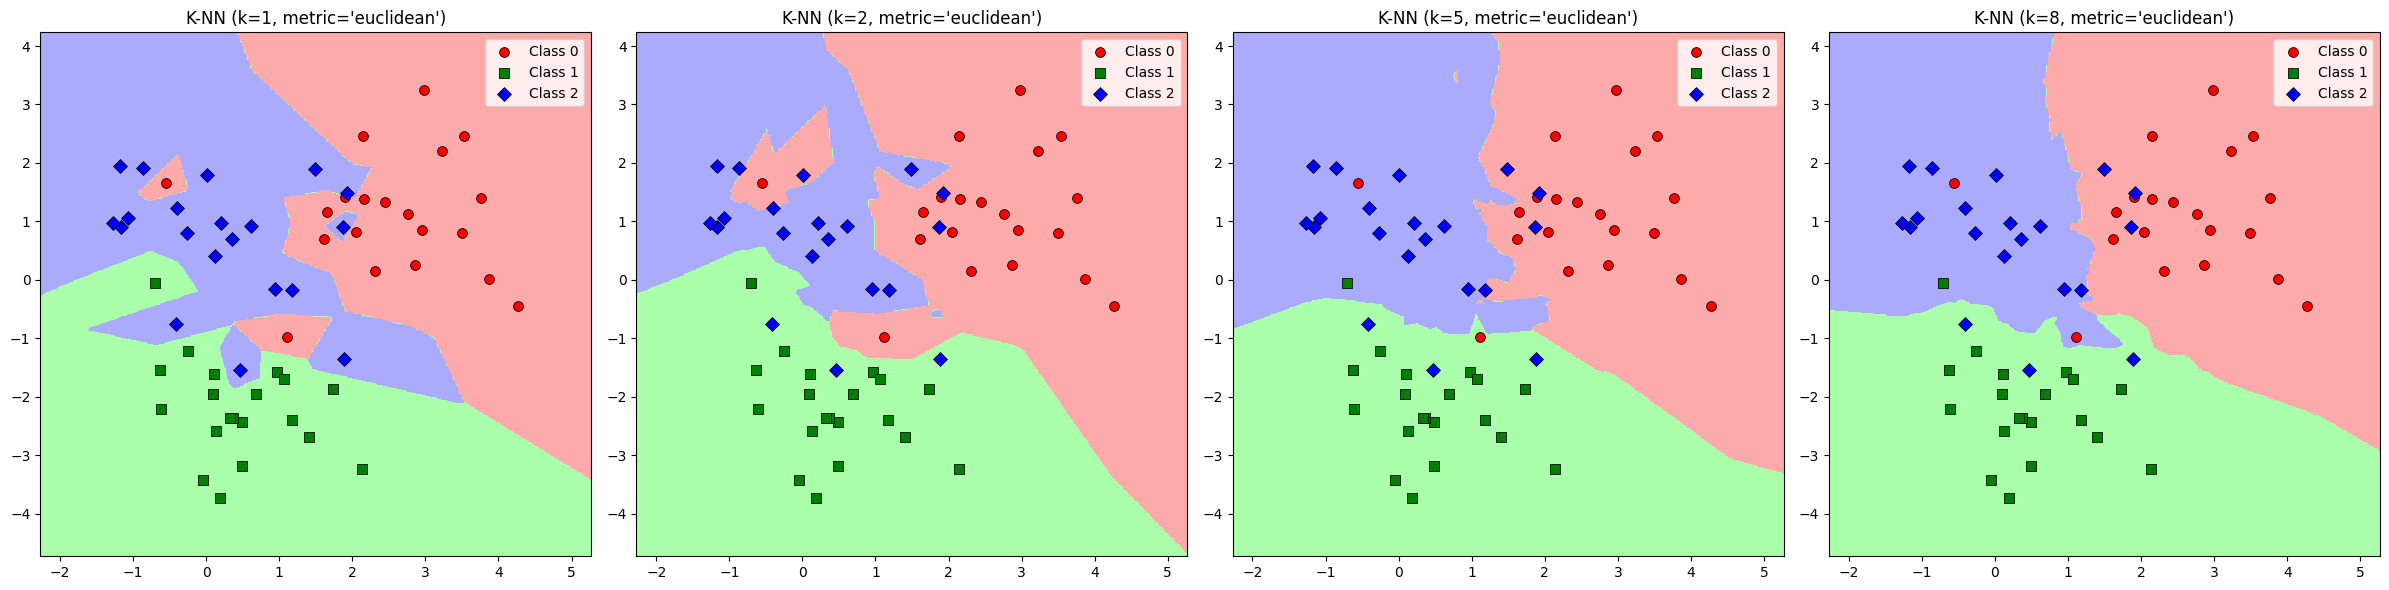

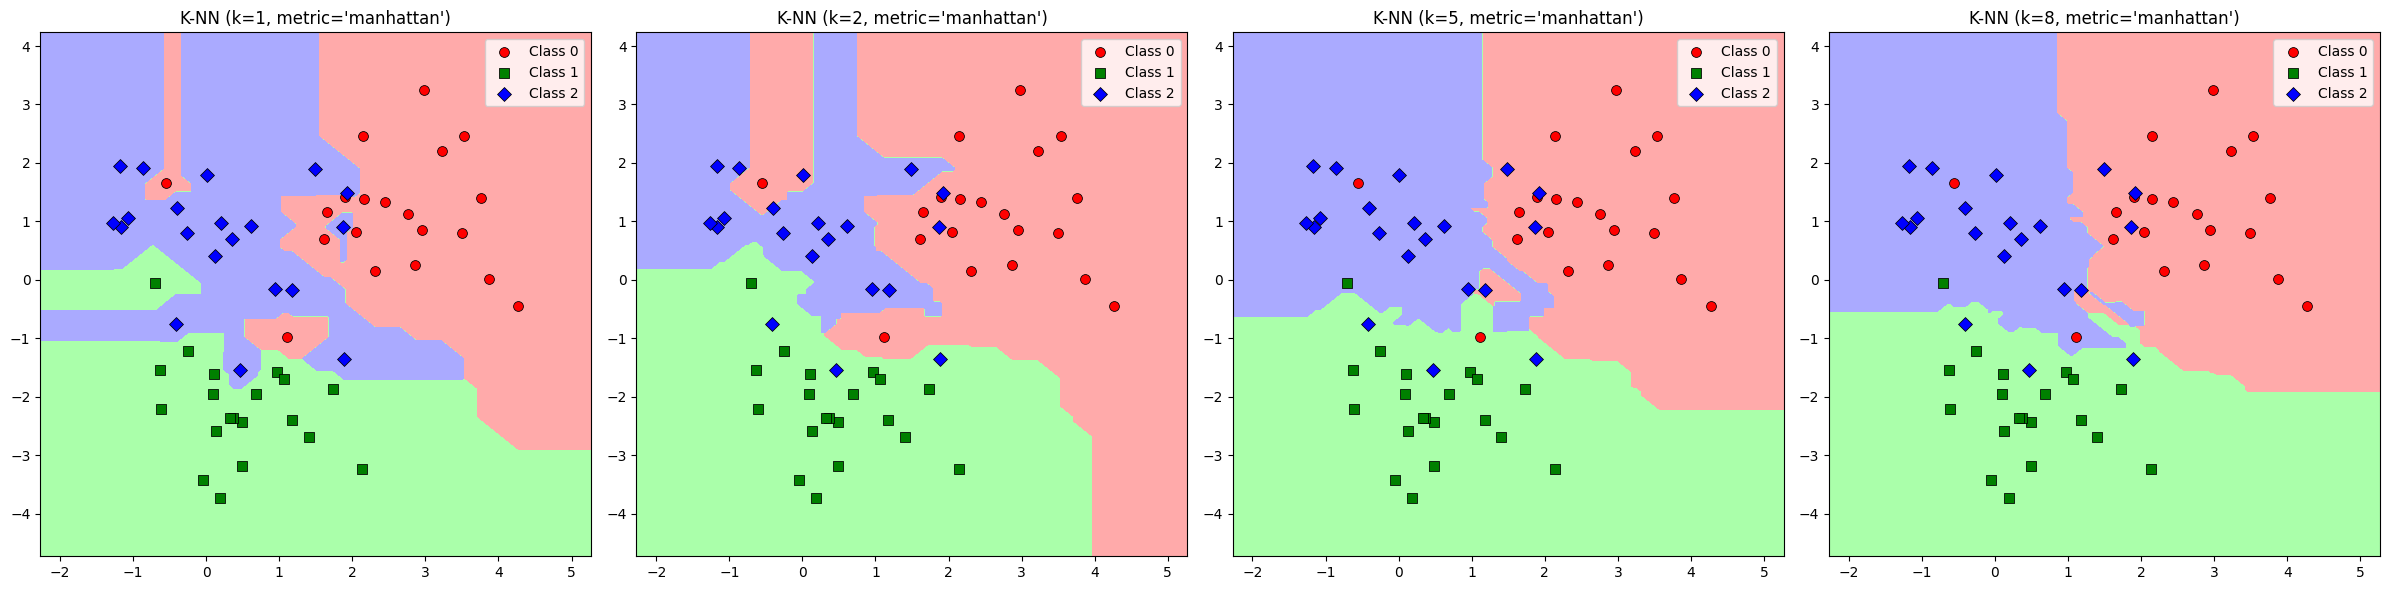

In [2]:
## provided toy dataset code
# load necessary packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

# Generate toy dataset, set seed to ensure reproducibility
np.random.seed(0)
n_points_per_class = 20

# create 3 overlapping classes of data
class1 = np.random.randn(n_points_per_class, 2) + [2, 1]
class2 = np.random.randn(n_points_per_class, 2) + [1, -2]
class3 = np.random.randn(n_points_per_class, 2) + [0, 0]

# combine these points into X and y datasets
X = np.vstack((class1, class2, class3))
y = np.array([0] * n_points_per_class + [1] * n_points_per_class + [2] * n_points_per_class)

# Plotting function to show decision boundaries
def plot_decision_boundaries(X, y, metric, ks):
    n_cols = len(ks)
    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 6, 6))

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']
    markers = ['o', 's', 'D']

    for ax, k in zip(axes, ks):
        clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
        clf.fit(X, y)

        h = .02  # step size in the mesh (just for plotting decision boundaries)
        # prep plotting parameters for groups and decision boundaries
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ## plotting the outputs
        ax.contourf(xx, yy, Z, cmap=cmap_light)
        for i, color, marker in zip(range(3), cmap_bold, markers):
            sns.scatterplot(ax=ax, x=X[y == i, 0], y=X[y == i, 1], marker=marker, color=color,
                            edgecolor='k', s=50, label=f'Class {i}')

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        # make sure to label the plot with the metric and value of k
        ax.set_title(f"K-NN (k={k}, metric='{metric}')")
        ax.legend()

    plt.tight_layout()
    plt.show()

# Choose distance metrics and vector of values of k to display
metrics = ['euclidean', 'manhattan']
ks = [1, 2, 5, 8]

# call function to plot decision boundaries for different metrics and values of k side-by-side
for metric in metrics:
    plot_decision_boundaries(X, y, metric, ks)

❓2.1.1 Briefly describe similarities and differences between the different values of $k$ in the plots above. How do the decision boundaries change with different values of $k$? Based on your knowledge of how the data were generated in the code above, are particular values of $k$ more or less accurate classifiers?

✅ Answer:

❓2.1.2 Based on the way these data were generated in the code above, are there particular classes of data that should be more or less difficult to separate from the other(s)? Do you see that reflected in the plots and decision boundaries?

✅ Answer:

❓2.1.3 Using the same data and the same values of k, run the k-NN algorithm again using a cosine distance metric. *Hint: You should just have to call the `plot_decision_boundaries` function written above with slightly different parameters.*

/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

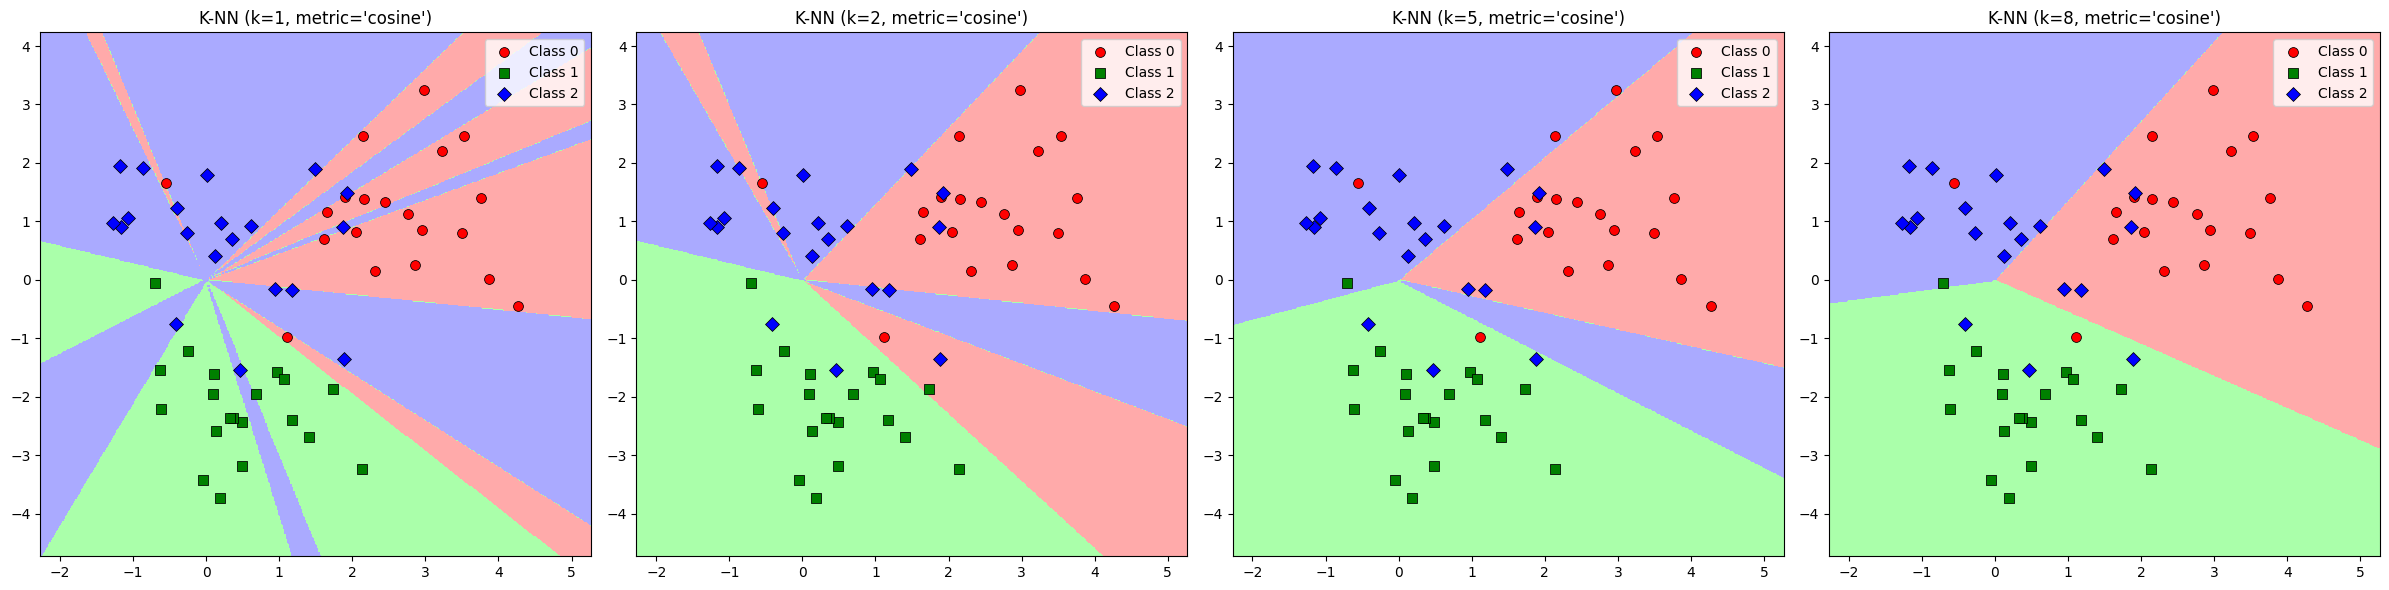

In [3]:
##❓YOUR CODE HERE
# Run the same toy-data experiment using cosine distance.
plot_decision_boundaries(X, y, metric='cosine', ks=ks)


❓2.1.4 Cosine similarity can be thought to measure "directionality" of the data. What kind of errors occur for this data and cosine distance? Based on how the data was generated, why is this the case?

✅Answer:

### 2.2: Splits & Cross-validation - choosing the best value of k

❓2.2.1 Choose an appropriate distance metric (*hint: not cosine similarity*) and add onto the code below to rerun the exercise above with cross-validation and test the vector of ks (`ks`) provided. Report the accuracy for each value of $k$ you test and create a plot of cross-validation accuracy vs. k. Add error bars for standard error of the mean to the cross-validation accuracy plots.

> A commented framework is provided below. Code blocks you need to complete are marked with `##❓YOUR CODE HERE` at the top.



In [4]:
## you don't need to modify this code block, just read it
## some newly necessary packages for cross-validation and error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score

# Generate toy dataset
np.random.seed(0)
n_points_per_class = 50

class1 = np.random.randn(n_points_per_class, 2) + [2, 1]
class2 = np.random.randn(n_points_per_class, 2) + [1, -2]
class3 = np.random.randn(n_points_per_class, 2) + [0, 0]

# combine these 3 classes of data together into one dataset and one set of class labels
X = np.vstack((class1, class2, class3))
y = np.array([0] * n_points_per_class + [1] * n_points_per_class + [2] * n_points_per_class)

# vector of k values to test with cross-validation
ks = range(1,31)

# make new plotting function to just deal with 1 value of k (no subplots of multiple values of k)
def plot_decision_boundaries_2(X, y, metric, k):
    fig, ax = plt.subplots(figsize=(6, 6))

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']
    markers = ['o', 's', 'D']

    clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
    clf.fit(X, y)

    h = .02  # step size in the mesh (just for plotting decision boundaries)
    # prep plotting parameters for groups and decision boundaries
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ## plotting the outputs
    ax.contourf(xx, yy, Z, cmap=cmap_light)
    for i, color, marker in zip(range(3), cmap_bold, markers):
        sns.scatterplot(ax=ax, x=X[y == i, 0], y=X[y == i, 1], marker=marker, color=color,
                        edgecolor='k', s=20, label=f'Class {i}')

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    # make sure to label the plot with the metric and value of k
    ax.set_title(f"K-NN (k={k}, metric='{metric}')")
    ax.legend()

    plt.tight_layout()
    plt.show()

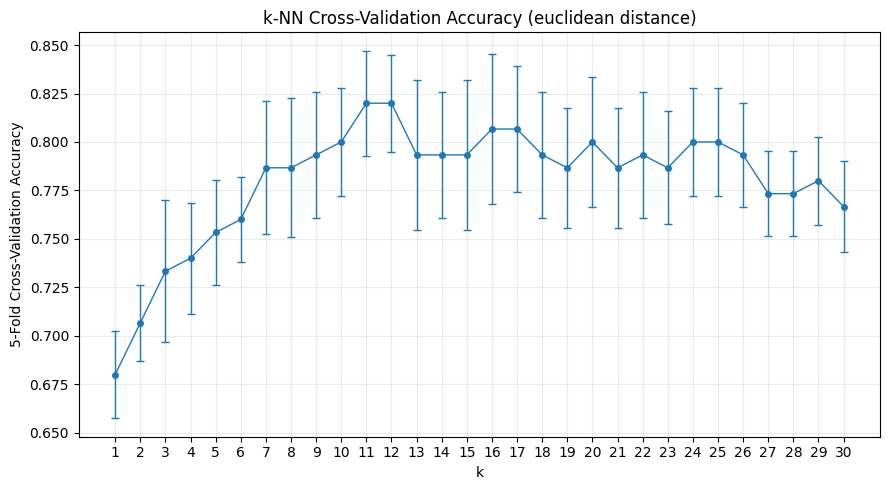

Best k: 11
Best mean CV accuracy: 0.8200


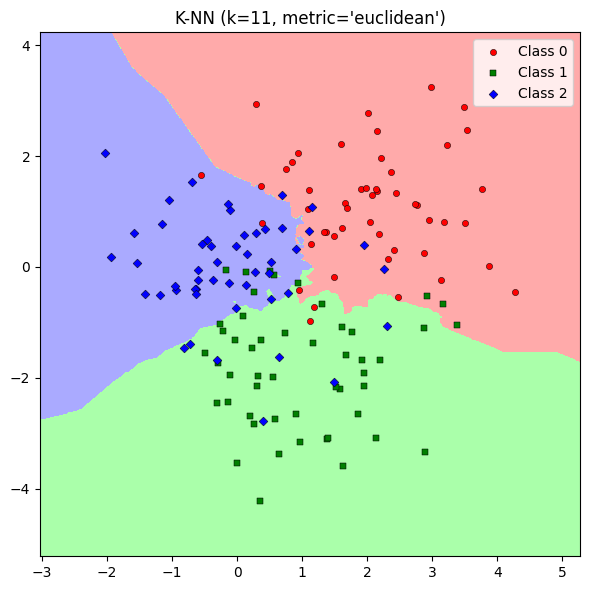

In [5]:
##❓YOUR CODE HERE
def evaluate_knn(X, y, ks, metric):
    # Write a function to fit the K-NN classifier and evaluate accuracy using 5-fold cross-validation
    # use random_state = 12 for the cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=12)
    accuracy_scores = {}

    # loop through different values of k to run cross-validation on each
    for k in ks:
        clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
        accuracy_scores[k] = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

    # return classification accuracy scores from the cross-validation
    return accuracy_scores

# choose a distance metric
metric = 'euclidean'
# apply the above function for your chosen distance metric
accuracy_scores = evaluate_knn(X, y, ks, metric)

# calculate mean and standard error of accuracy across the 5 folds of cross-validation
mean_accuracies = [np.mean(accuracy_scores[k]) for k in ks]
sem_accuracies = [np.std(accuracy_scores[k], ddof=1)/np.sqrt(5) for k in ks]

# Plot accuracy with error bars for each value of k
plt.figure(figsize=(9, 5))
plt.errorbar(
    list(ks),
    mean_accuracies,
    yerr=sem_accuracies,
    fmt='o-',
    capsize=3,
    markersize=4,
    linewidth=1
)
plt.xlabel('k')
plt.ylabel('5-Fold Cross-Validation Accuracy')
plt.title(f'k-NN Cross-Validation Accuracy ({metric} distance)')
plt.xticks(list(ks))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# find the best value of k and the corresponding accuracy
# Choose the smallest k among ties, which gives a reproducible and conservative tie-break.
best_accuracy = np.max(mean_accuracies)
best_k = min(k for k, score in zip(ks, mean_accuracies) if np.isclose(score, best_accuracy))
# make sure to print out the best value of k and corresponding accuracy
print(f'Best k: {best_k}')
print(f'Best mean CV accuracy: {best_accuracy:.4f}')

# Plot decision boundaries for the best value of k (not all values of k!)
plot_decision_boundaries_2(X, y, metric, best_k)


❓2.2.2 What is the best value of k for these data? Based on the plots of average cross-validation accuracy across various values of k, recommend and defend a range of appropriate values of k.

✅ Answer:

## Section 3: tSNE! (PBMCs)

### 3.1: Load the Data and Manipulate

❓3.1.1 Load the provided file of scRNA-seq data as a pandas dataframe. Visualize just the first few rows and *and only the first few columns* of the data -- as described in the background document, there are thousands of cells (columns) in this dataset.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the local PBMC expression matrix.
DATA_DIR = Path('.')
PBMC_PATH = DATA_DIR / 'data_03_pbmc.txt'
if not PBMC_PATH.exists():
    PBMC_PATH = Path('/mnt/data/data_03_pbmc.txt')

pbmc_df = pd.read_csv(PBMC_PATH, sep='\t', header=0, index_col=0)
print(f'Loaded {PBMC_PATH}')
print(f'PBMC expression matrix shape: {pbmc_df.shape}')


Loaded data_03_pbmc.txt
PBMC expression matrix shape: (2000, 2638)


In [7]:
##❓YOUR CODE HERE
# load the pbmc data as a pandas df
# (The dataframe is loaded in the previous cell as pbmc_df.)

# Look at the top of the data. Only display the first few rows and columns.
pbmc_df.iloc[:5, :5]


,AAACATACAACCAC-1,AAACATTGAGCTAC-1,AAACATTGATCAGC-1,AAACCGTGCTTCCG-1,AAACCGTGTATGCG-1
PPBP,0.000000,0.000000,0.000000,1.566387,0.000000
LYZ,1.635873,1.962726,1.995416,4.521175,0.000000
S100A9,0.000000,0.000000,0.000000,3.838845,0.000000
IGLL5,0.000000,0.000000,0.000000,0.000000,0.000000
GNLY,0.000000,0.000000,1.429744,0.000000,3.453545


❓3.1.2 Transpose your loaded pandas df to make the observations (cells) into rows to make it compatible with `scikitlearn`.

In [8]:
##❓YOUR CODE HERE
# transpose the pbmc df so cells are rows and genes are columns
pbmc_cells = pbmc_df.T

# check that it's the size/shape you expect
print('Cells x genes shape:', pbmc_cells.shape)
print('First cell:', pbmc_cells.index[0])
print('First few genes:', pbmc_cells.columns[:5].tolist())
pbmc_cells.head()


Cells x genes shape: (2638, 2000)
First cell: AAACATACAACCAC-1
First few genes: ['PPBP', 'LYZ', 'S100A9', 'IGLL5', 'GNLY']


,PPBP,LYZ,S100A9,IGLL5,GNLY,FTL,PF4,FTH1,GNG11,S100A8,...,GADD45G,MKNK1,AURKC,VOPP1,RHOC,CISH,CD27,LILRA3,CLIC2,HEMGN
AAACATACAACCAC-1,0.000000,1.635873,0.000000,0.0,0.000000,3.924095,0.0,2.226555,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,3.075915,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.000000,1.962726,0.000000,0.0,0.000000,3.063189,0.0,3.574384,0.0,0.000000,...,0.000000,0.0,0.0,1.111715,0.0,0.0,1.111715,0.0,0.0,0.0
AAACATTGATCAGC-1,0.000000,1.995416,0.000000,0.0,1.429744,3.274161,0.0,3.582238,0.0,0.000000,...,1.429744,0.0,0.0,0.000000,0.0,0.0,1.429744,0.0,0.0,0.0
AAACCGTGCTTCCG-1,1.566387,4.521175,3.838845,0.0,0.000000,5.692271,0.0,5.919842,0.0,2.515108,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
AAACCGTGTATGCG-1,0.000000,0.000000,0.000000,0.0,3.453545,5.218589,0.0,3.453545,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


### 3.2: Make a t-SNE Plot

❓3.2.1 Use scikitlearn to make a t-SNE embeddings of these PBMCs.

In [9]:
from sklearn.manifold import TSNE
##❓YOUR CODE HERE
# make and display a t-SNE in 2 dimensions
# Create a t-SNE model in 2-D and fit it to the cell-by-gene data
tsne = TSNE(n_components=2, random_state=12, init='pca', learning_rate='auto')
tsne_embedding = tsne.fit_transform(pbmccells := pbmc_cells.to_numpy())

print('t-SNE embedding shape:', tsne_embedding.shape)


/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sarahjiang/Desktop/teaching/bme3

t-SNE embedding shape: (2638, 2)


❓3.2.2 Plot your embeddings! Since there are a lot of cells that will pile up on top of each other, be sure to adjust `alpha` to make the points a bit transparent and avoid overplotting.

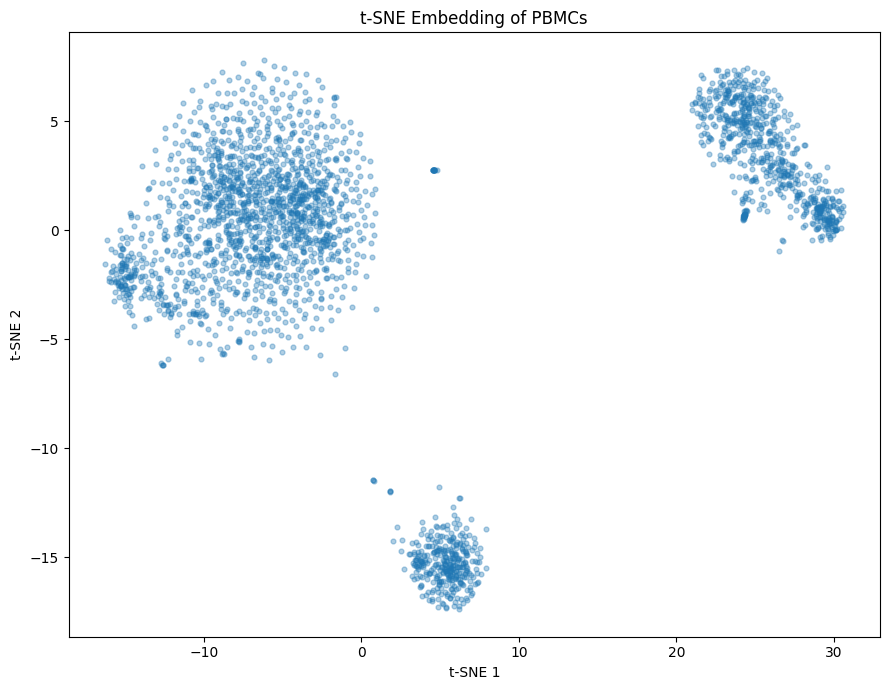

In [10]:
##❓YOUR CODE HERE
# Plot the t-SNE embedding
plt.figure(figsize=(9, 7))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], s=12, alpha=0.35)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Embedding of PBMCs')
plt.tight_layout()
plt.show()


### 3.3: Color the t-SNE Plot by Marker Gene Expressions

❓3.3.1 Remake the plot you made above, but color it by the expression (counts) of the marker genes on the list below (making 4 plots). Make sure to add a colorbar to each to understand the scale. Skeleton code is provided.


Marker genes:
- MS4A1
- PPBP
- LYZ
- CD74

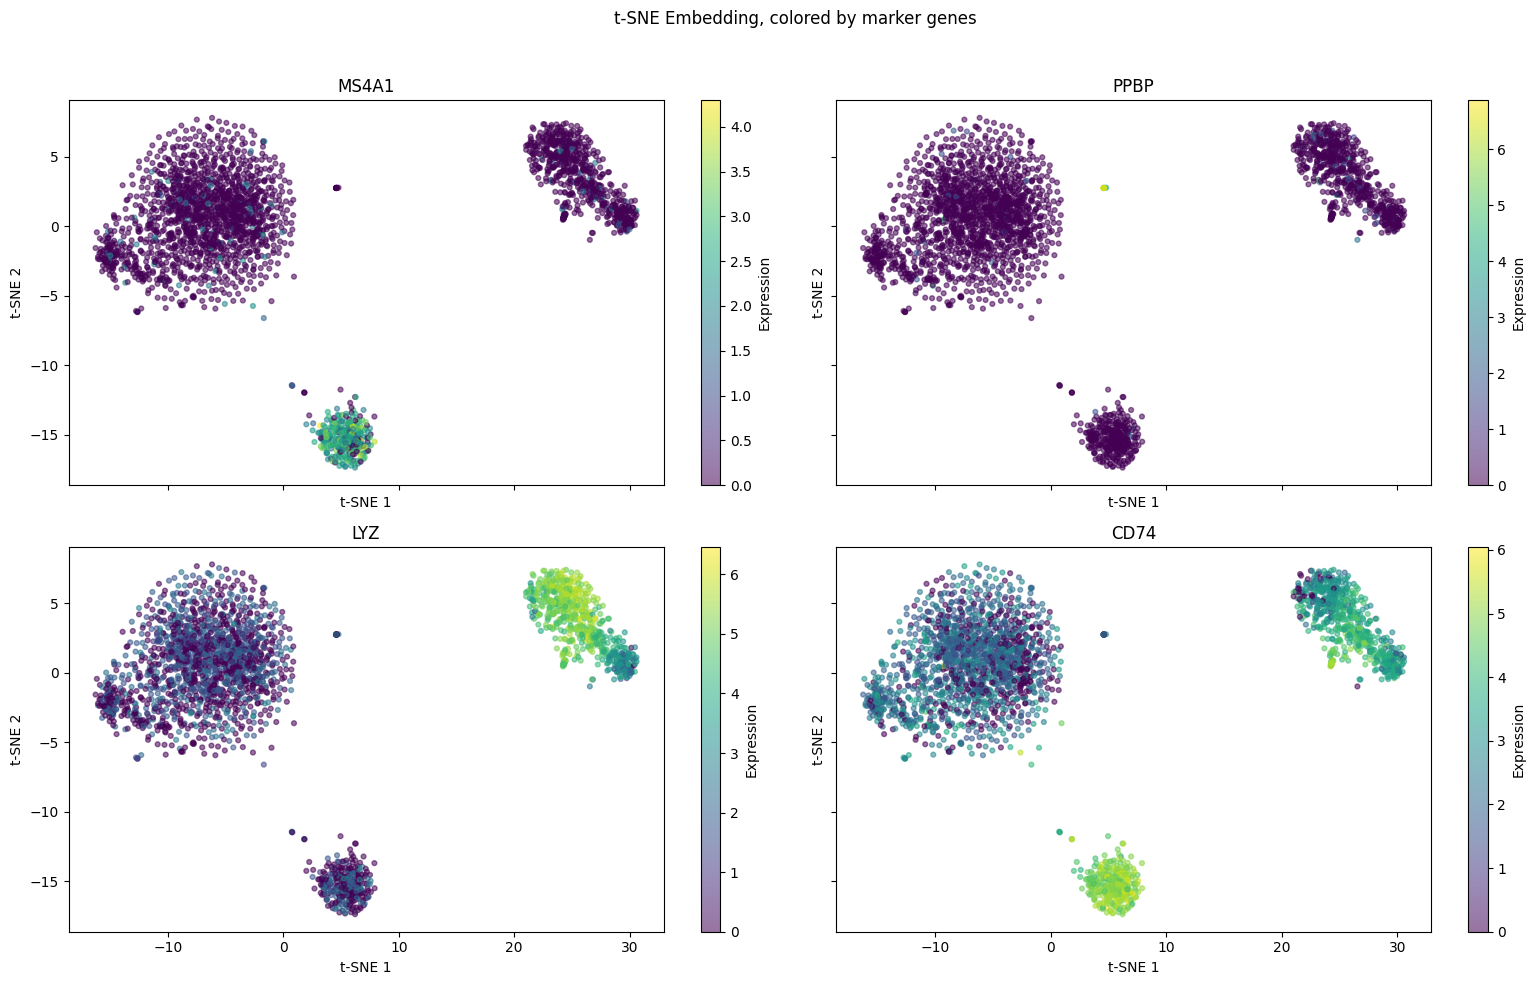

In [11]:
##❓YOUR CODE HERE
# make the plot above, but colored by the marker genes
# remember to add a color bar for scale
# label the plots with the gene name

# Use the four marker genes specified in the question.
markers = ["MS4A1", "PPBP", "LYZ", "CD74"]

# set up figure for plotting with subplots
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(16, 10))
fig.suptitle('t-SNE Embedding, colored by marker genes')
axes = [ax[0, 0], ax[0, 1], ax[1, 0], ax[1, 1]]

# write a function to put the marker gene into the appropriate subplot
def plot_my_gene(marker_gene, axis):
    if marker_gene not in pbmc_cells.columns:
        raise KeyError(f'{marker_gene} is not present in the PBMC expression matrix.')

    expression = pbmc_cells[marker_gene].to_numpy()
    scatter = axis.scatter(
        tsne_embedding[:, 0],
        tsne_embedding[:, 1],
        c=expression,
        s=12,
        alpha=0.55,
        cmap='viridis'
    )
    axis.set_title(marker_gene)
    axis.set_xlabel('t-SNE 1')
    axis.set_ylabel('t-SNE 2')
    fig.colorbar(scatter, ax=axis, label='Expression')

# map the function across the list of marker genes and subplots
list(map(plot_my_gene, markers, axes))

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


❓3.3.2 Looking at the plots above, **do you think the marker gene(s) do a good job differentiating the various celltypes present in this dataset? In particular, what is the PPBP plot showing?** Assume here that "cell type" refers to cells that are neighbors - we expect some transcriptional variation within a cell type, but cells within a particular cell type are generally similar and are neighbors in high-dimensional transcriptional "space."

*Please only give a couple sentences description as a brief answer.*

✅ Answer:

### 3.4: Color tSNE by external labels
❓3.4.1 Run the codeblock below to load in the celltype labels, which are in the same order as the original columns of the PBMC dataframe. Plot your tSNE embeddings colored by the provided celltype labels.

In [12]:
# Load the celltype labels as a pandas dataframe
from pathlib import Path

IDENT_PATH = DATA_DIR / 'data_04_pbmcidents.txt'
if not IDENT_PATH.exists():
    IDENT_PATH = Path('/mnt/data/data_04_pbmcidents.txt')

pbmc_idents = pd.read_csv(IDENT_PATH, header=0, sep='\t', quotechar='"', quoting=0)
pbmc_idents['ident'] = pbmc_idents['ident'].astype(str)

# check that we've got labels
pbmc_idents.head(10)


,ident
AAACATACAACCAC-1,Memory.CD4
AAACATTGAGCTAC-1,B
AAACATTGATCAGC-1,Memory.CD4
AAACCGTGCTTCCG-1,CD14.Mono
AAACCGTGTATGCG-1,NK
AAACGCACTGGTAC-1,Memory.CD4
AAACGCTGACCAGT-1,CD8.T
AAACGCTGGTTCTT-1,CD8.T
AAACGCTGTAGCCA-1,Naive.CD4.T
AAACGCTGTTTCTG-1,FCGR3A.Mono


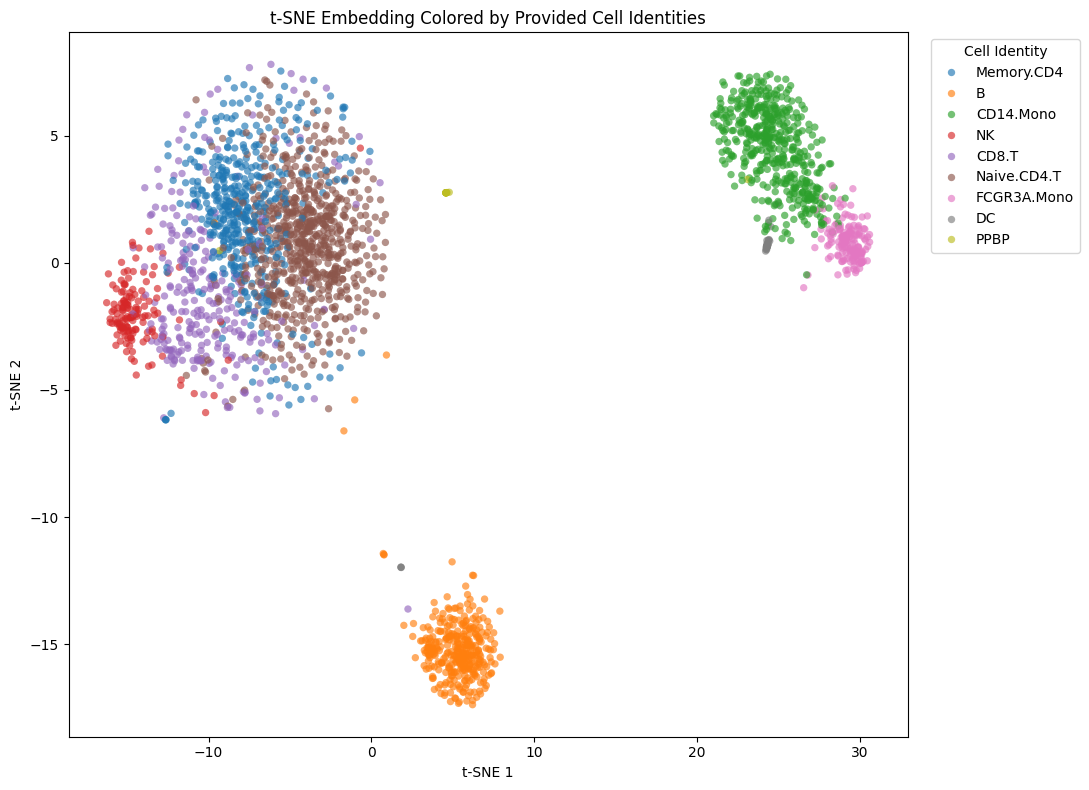

In [13]:
# import seaborn to make plotting easier with labels
import seaborn as sns
##❓YOUR CODE HERE
# first combine the t-SNE embeddings with the labels into 1 df
if len(pbmc_idents) != len(tsne_embedding):
    raise ValueError(
        f'Number of labels ({len(pbmc_idents)}) does not match number of cells ({len(tsne_embedding)}).'
    )

tsne_df = pd.DataFrame({
    'tsne_1': tsne_embedding[:, 0],
    'tsne_2': tsne_embedding[:, 1],
    'identity': pbmc_idents['ident'].to_numpy(),
})

# use seaborn to plot nicely and generate automatic labels of your celltypes
plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=tsne_df,
    x='tsne_1',
    y='tsne_2',
    hue='identity',
    s=28,
    alpha=0.65,
    linewidth=0
)
plt.title('t-SNE Embedding Colored by Provided Cell Identities')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cell Identity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## ⭐ Bonus - Section 4: A Return to kNN - PBMCs

Now we're going to try using k-NN to group the PBMC data and compare the classifications kNN produces to the t-SNE embedding.

⭐ 4.1 Apply 8-NN to the pbmc dataset, randomly splitting the cells into 80% training and 20% test sets. Then plot the test data's tSNE embeddings and color 2 ways: the true cell identities and the **8-NN** assignments.

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Split the dataset into train and test sets. Stratification preserves
# the overall distribution of cell identities in both sets.
X_pbmc = pbmc_cells.to_numpy()
y_pbmc = pbmc_idents['ident'].to_numpy()
cell_ids = pbmc_cells.index.to_numpy()

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X_pbmc,
    y_pbmc,
    cell_ids,
    test_size=0.20,
    random_state=12,
    stratify=y_pbmc,
)

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)

# recombine train and test to redo the t-SNE embeddings
X_all = np.vstack([X_train, X_test])
ids_all = np.concatenate([ids_train, ids_test])
y_all = np.concatenate([y_train, y_test])

# redo the tsne embeddings; t-SNE must be fit to all cells together
tsne_all = TSNE(n_components=2, random_state=12, init='pca', learning_rate='auto')
tsne_all_embedding = tsne_all.fit_transform(X_all)

# Recover the test rows in the same order as X_test. Because train_test_split
# shuffles the data, use cell IDs rather than assuming contiguous rows.
id_to_position = {cell_id: i for i, cell_id in enumerate(ids_all)}
test_positions = np.array([id_to_position[cell_id] for cell_id in ids_test])

tsne_df_test = pd.DataFrame({
    'tsne_1': tsne_all_embedding[test_positions, 0],
    'tsne_2': tsne_all_embedding[test_positions, 1],
    'identity': y_test,
})

print('Test t-SNE shape:', tsne_df_test.shape)


Training shape: (2110, 2000)
Test shape: (528, 2000)


/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sarahjiang/Desktop/teaching/bme304-704-lab/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/sarahjiang/Desktop/teaching/bme3

Test t-SNE shape: (528, 3)


Training accuracy: 0.803
Test accuracy: 0.722


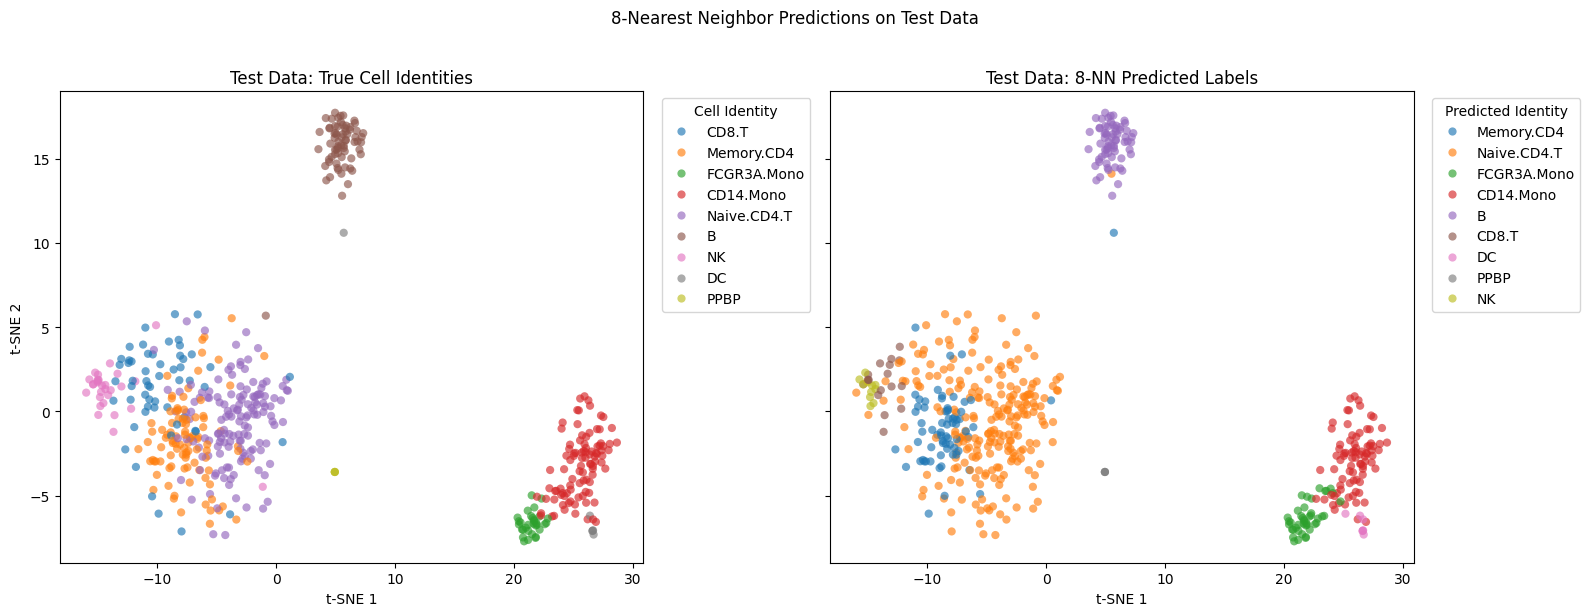

In [15]:
##❓YOUR CODE HERE

# Create a KNN classifier with 8 neighbors
knn = KNeighborsClassifier(n_neighbors=8, metric='euclidean')

# fit the model on the training data
knn.fit(X_train, y_train)

# apply the model to make predictions on training and test data
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

print(f'Training accuracy: {(y_train_pred == y_train).mean():.3f}')
print(f'Test accuracy: {(y_test_pred == y_test).mean():.3f}')

# add the model predictions to the test t-SNE dataframe
tsne_df_test['predicted'] = y_test_pred
tsne_df_test['label_type'] = 'True identity'

# Plot just the test data: true identities vs predicted class labels
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=tsne_df_test, x='tsne_1', y='tsne_2', hue='identity',
    s=35, alpha=0.65, linewidth=0, ax=axes[0]
)
axes[0].set_title('Test Data: True Cell Identities')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(title='Cell Identity', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.scatterplot(
    data=tsne_df_test, x='tsne_1', y='tsne_2', hue='predicted',
    s=35, alpha=0.65, linewidth=0, ax=axes[1]
)
axes[1].set_title('Test Data: 8-NN Predicted Labels')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(title='Predicted Identity', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle('8-Nearest Neighbor Predictions on Test Data', y=1.02)
plt.tight_layout()
plt.show()


⭐ 4.2 Report the model accuracy to give an idea of how this 8-NN model does overall. Because we have several different cell identities and the model does not appear to perform equally well across all identities, also use the [`classification_report` function](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) to give a more detailed breakdown across cell types.

In [16]:
from sklearn.metrics import classification_report
##❓YOUR CODE HERE
# Evaluate the model on the test set
test_accuracy = np.mean(y_test_pred == y_test)

# Suggestions for nice printing for TAs
print(f'Test accuracy: {test_accuracy:.2f}')

# print classification report
print(classification_report(y_test, y_test_pred, zero_division=0))


Test accuracy: 0.72
              precision    recall  f1-score   support

           B       1.00      0.97      0.99        69
   CD14.Mono       1.00      0.86      0.93        96
       CD8.T       0.29      0.09      0.14        56
          DC       0.71      0.83      0.77         6
 FCGR3A.Mono       0.74      1.00      0.85        32
  Memory.CD4       0.62      0.44      0.52        95
          NK       1.00      0.38      0.55        29
 Naive.CD4.T       0.58      0.94      0.72       142
        PPBP       1.00      1.00      1.00         3

    accuracy                           0.72       528
   macro avg       0.77      0.72      0.72       528
weighted avg       0.72      0.72      0.69       528



⭐4.3 Look back at your graph above. Do the model assignments match the provided labels on the data in general?  Briefly describe visual differences between the predicted and given cell identity classes. Are there particular clusters on which the 8-NN model appears to do better or worse? Do the t-SNE embeddings help explain why the model succeeds and fails at identifying in particular cell types?

🍓Answer: